# Détection des zones de sous-desserte (Classification)

**Problématique** : Détecter les zones de sous-desserte ou fragiles — classification des relations présentant un risque stratégique.

**Objectif** : Prédire le `desserte_type` d'une relation ferroviaire à partir de ses caractéristiques.

## Imports & Configuration

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn joblib


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score,
    balanced_accuracy_score, matthews_corrcoef
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import RandomizedSearchCV, learning_curve
from scipy.stats import randint, uniform

In [3]:
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42

## Chargement des données

**! Attention connecter api ici**

In [4]:
INPUT_FOLDER = "../../../data/output"

csv_files = glob.glob(os.path.join(INPUT_FOLDER, "*.csv"))
print(f"Fichiers trouvés : {[os.path.basename(f) for f in csv_files]}")

dfs = []
for filepath in csv_files:
    df_tmp = pd.read_csv(filepath)
    print(f"{os.path.basename(filepath)} : {len(df_tmp)} lignes")
    dfs.append(df_tmp)

df_raw = pd.concat(dfs, ignore_index=True)


print(f"\n Dataset combiné : {df_raw.shape[0]} lignes")
df_raw.head()

Fichiers trouvés : ['austria_etl.csv', 'belgium_weekly_trains.csv', 'germany_etl.csv', 'sncf_routes_stats.csv', 'spain_etl.csv', 'switzerland_etl.csv']
austria_etl.csv : 3683 lignes
belgium_weekly_trains.csv : 15499 lignes
germany_etl.csv : 876 lignes
sncf_routes_stats.csv : 4465 lignes
spain_etl.csv : 680 lignes
switzerland_etl.csv : 47364 lignes

 Dataset combiné : 72567 lignes


,data_source,route_id,id_origin_city,id_destination_city,weekly_train,desserte_type,origin_city,destination_city
0,austria,1-80-j26-1,at:49:1349:0:10,at:43:4132:0:1,1,Sous-desservi,NaN,NaN
1,austria,1-MB4-j26-1,at:48:130:0:12,at:48:134:0:8,37,Desserte Normale,NaN,NaN
2,austria,1-MB4-j26-1,at:48:134:0:8,at:48:130:0:1,1,Sous-desservi,NaN,NaN
3,austria,1-MB4-j26-1,at:48:134:0:8,at:48:130:0:10,3,Sous-desservi,NaN,NaN
4,austria,1-MB4-j26-1,at:48:134:0:8,at:48:130:0:4,37,Desserte Normale,NaN,NaN


## Exploration des données

In [5]:
print("Types :")
print(df_raw.dtypes)
print("\nValeurs manquantes :")
print(df_raw.isnull().sum())

Types :
data_source            object
route_id               object
id_origin_city         object
id_destination_city    object
weekly_train            int64
desserte_type          object
origin_city            object
destination_city       object
dtype: object

Valeurs manquantes :
data_source                0
route_id                   0
id_origin_city         19964
id_destination_city    19964
weekly_train               0
desserte_type              0
origin_city            52603
destination_city       52603
dtype: int64


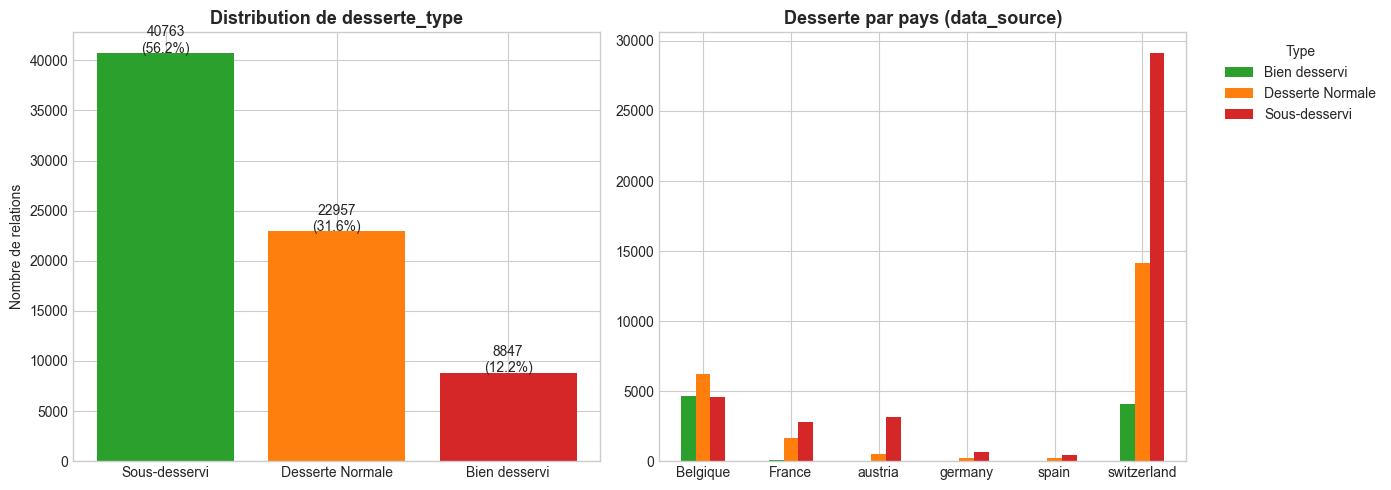

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution de la target
counts = df_raw['desserte_type'].value_counts()
colors = ['#2ca02c', '#ff7f0e', '#d62728']
axes[0].bar(counts.index, counts.values, color=colors[:len(counts)])
axes[0].set_title('Distribution de desserte_type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de relations')
for i, (idx, val) in enumerate(counts.items()):
    axes[0].text(i, val + 20, f'{val}\n({val/len(df_raw)*100:.1f}%)', ha='center', fontsize=10)

# Distribution par pays
pivot = df_raw.groupby(['data_source', 'desserte_type']).size().unstack(fill_value=0)
pivot.plot(kind='bar', ax=axes[1], color=colors[:pivot.shape[1]])
axes[1].set_title('Desserte par pays (data_source)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Type', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

## Préparation des features

In [7]:
df = df_raw.copy()

FEATURES = ['data_source', 'weekly_train']
TARGET   = 'desserte_type'

# Encodage des variables catégorielles
source = LabelEncoder()
df['data_source_enc'] = source.fit_transform(df['data_source'].astype(str))

# Encodage de la target
target = LabelEncoder()
df['target_enc'] = target.fit_transform(df[TARGET])

FEATURE_COLS = ['data_source_enc', 'weekly_train']

X = df[FEATURE_COLS].values
y = df['target_enc'].values

# Startify == prend un peu de toute les data pour faire le train et le test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train : {X_train.shape[0]}")
print(f"Test  : {X_test.shape[0]}")

Train : 58053
Test  : 14514


## Entraînement & Comparaison des modèles

Modèles testés :
- **Logistic Regression**
- **Random Forest**
- **Gradient Boosting**

In [8]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest' : RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc) if hasattr(model, 'predict_proba') else None

    # Cross-validation F1-score
    cv_f1 = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='f1').mean()

    row = {
        'Modèle' : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'F1' : f1_score(y_test, y_pred, average='weighted'),
        'Precision' : precision_score(y_test, y_pred, average='macro'),
        'Recall' : recall_score(y_test, y_pred, average='macro'),
    }

    results.append(row)
    print(f"{name}")

df_results = pd.DataFrame(results).set_index('Modèle')

Logistic Regression
Random Forest
Gradient Boosting


## Tableau de métriques comparatif

In [9]:
pd.set_option('display.float_format', '{:.4f}'.format)
styled = df_results.style\
    .background_gradient(cmap='RdYlGn', subset=['Accuracy','F1'])\
    .format('{:.4f}')\
    .set_caption('Comparaison des métriques')
styled

,Accuracy,F1,Precision,Recall
Modèle,,,,
Logistic Regression,0.9822,0.9820,0.9832,0.9812
Random Forest,1.0000,1.0000,1.0000,1.0000
Gradient Boosting,1.0000,1.0000,1.0000,1.0000


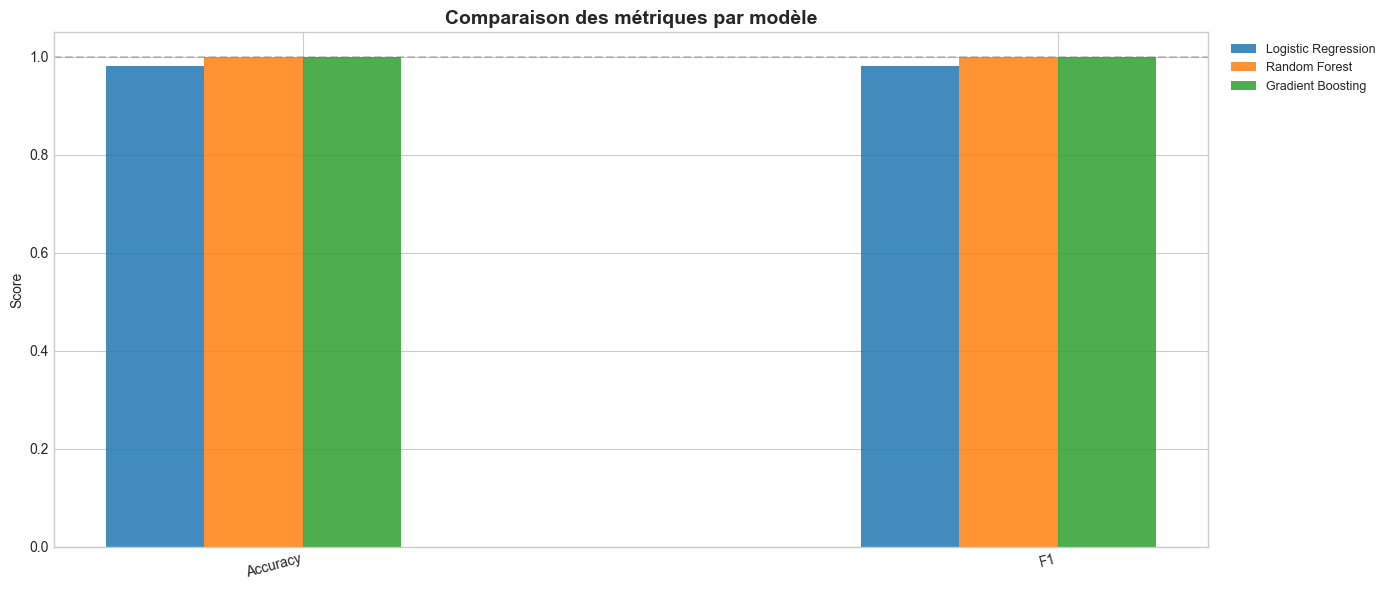

In [10]:
# Visualisation radar / bar chart des métriques clés
metrics_to_plot = ['Accuracy', 'F1']
df_plot = df_results[metrics_to_plot].dropna(axis=1)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(df_plot.columns))
width = 0.13

for i, (model_name, row) in enumerate(df_plot.iterrows()):
    offset = (i - len(df_plot)/2) * width
    bars = ax.bar(x + offset, row.values, width, label=model_name, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(df_plot.columns, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_title('Comparaison des métriques par modèle', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Learning Curves (Avant optimisation)

La **learning curve** montre comment la performance évolue en fonction du nombre d'exemples d'entraînement.
- Si le score train > score val → **overfitting** (le modèle a trop appris les données train)
- Si les deux scores sont bas → **underfitting** (modèle pas assez puissant)
- Si les deux scores convergent → modèle bien équilibré

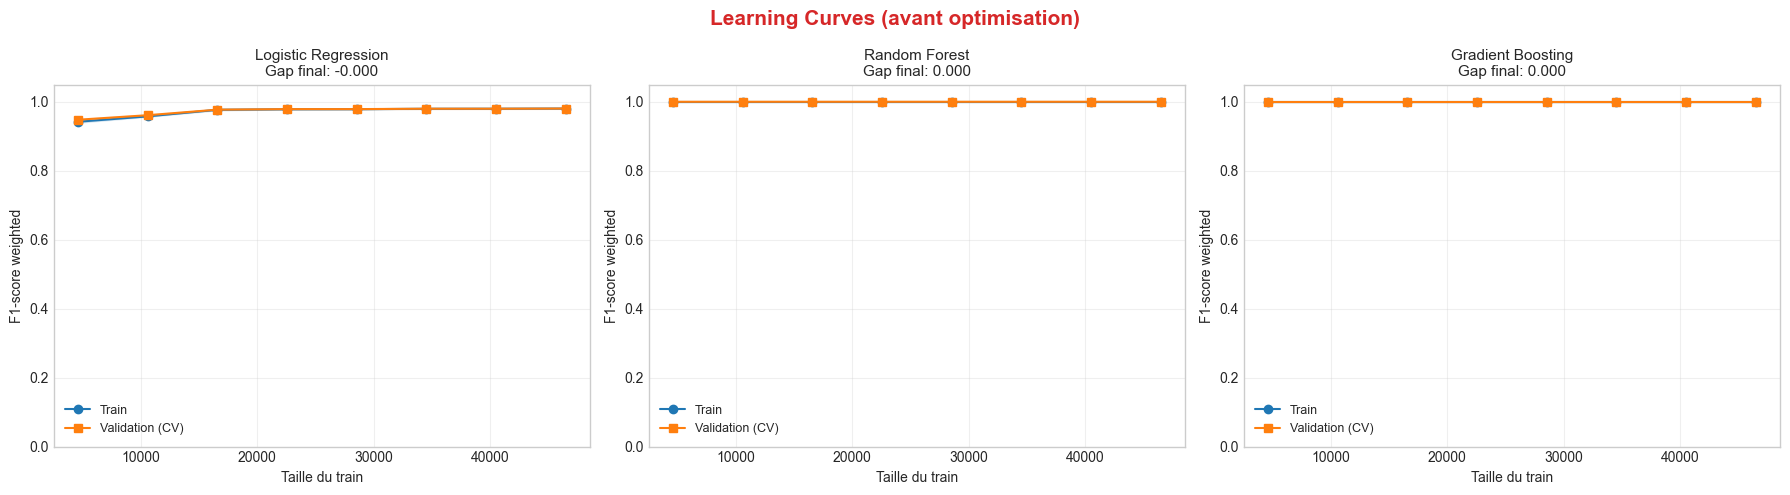

In [11]:
# Learning curves AVANT optimisation pour chaque modèle
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, len(models), figsize=(18, 5))
fig.suptitle('Learning Curves (avant optimisation)', fontsize=15, fontweight='bold', color='#d62728')

train_sizes = np.linspace(0.1, 1.0, 8)

for ax, (name, model) in zip(axes, models.items()):
    train_sz, train_scores, val_scores = learning_curve(
        model, X_train_sc, y_train,
        train_sizes=train_sizes,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring='f1_weighted',
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sz, train_mean, 'o-', color='#1f77b4', label='Train')
    ax.fill_between(train_sz, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#1f77b4')
    ax.plot(train_sz, val_mean, 's-', color='#ff7f0e', label='Validation (CV)')
    ax.fill_between(train_sz, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#ff7f0e')

    gap = (train_mean[-1] - val_mean[-1])
    ax.set_title(f'{name}\nGap final: {gap:.3f}', fontsize=11)
    ax.set_xlabel('Taille du train')
    ax.set_ylabel('F1-score weighted')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Optimisation des hyperparamètres (RandomizedSearchCV)

### Pourquoi RandomizedSearchCV plutôt que GridSearchCV ?
| | **GridSearchCV** | **RandomizedSearchCV** |
|---|---|---|
| Méthode | Teste **toutes** les combinaisons | Tire aléatoirement `n_iter` combinaisons |
| Temps | Très lent si beaucoup de params | **Beaucoup plus rapide** |
| Résultat | Optimal garanti | Quasi-optimal dans le temps imparti |
| Usage | Petits espaces | **Grands espaces de recherche** |

On utilise une **cross-validation stratifiée** (StratifiedKFold) à l'intérieur pour évaluer chaque combinaison sans toucher au test set.

In [12]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Espaces d'hyperparamètres à explorer
param_distributions = {
    'Random Forest': {
        'n_estimators'      : randint(20, 50), # nombre d'arbres
        'max_depth'         : [None, 5, 10, 20, 30], # profondeur max
        'min_samples_split' : randint(2, 15), # min échantillons pour splitter
        'min_samples_leaf'  : randint(1, 5), # min échantillons par feuille
        'max_features'      : ['sqrt', 'log2', None], # features testées à chaque split
        'class_weight'      : ['balanced', None]
    },
    'Gradient Boosting': {
        'n_estimators'  : randint(20, 50),
        'learning_rate' : uniform(0.01, 0.3), # distribution uniforme [0.01, 0.31]
        'max_depth'     : randint(2, 3),
        'subsample'     : uniform(0.6, 0.4), # fraction des données par arbre
        'min_samples_split': randint(2, 10),
    },
    'Logistic Regression': {
        'C'       : uniform(0.01, 10), # force de régularisation (inverse)
        'solver'  : ['lbfgs', 'saga'],
        'penalty' : ['l2', None],
        'class_weight': ['balanced', None]
    }
}

cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
optimized_models = {}
search_results = []

print("Lancement du RandomizedSearchCV...")

for name, model in models.items():
    print(f"\n Optimisation : {name}")
    
    rscv = RandomizedSearchCV(
        estimator  = model,
        param_distributions = param_distributions[name],
        n_iter = 50, # nombre de combinaisons testées
        cv = cv_inner, # cross-validation interne
        scoring = 'f1_weighted', # métrique d'optimisation
        n_jobs = -1, # parallélisation
        random_state = RANDOM_STATE,
        verbose = 0
    )
    rscv.fit(X_train_sc, y_train)
    
    optimized_models[name] = rscv.best_estimator_
    
    # Évaluation sur le test set
    y_pred_opt = rscv.best_estimator_.predict(X_test_sc)
    f1_opt = f1_score(y_test, y_pred_opt, average='weighted')
    f1_avant = df_results.loc[name, 'F1']
    
    print(f" Meilleurs params : {rscv.best_params_}")
    print(f" F1 CV (best) : {rscv.best_score_:.4f}")
    print(f" F1 Test Avant : {f1_avant:.4f}")
    print(f" F1 Test Après : {f1_opt:.4f}  {'' if f1_opt > f1_avant else ''}{f1_opt - f1_avant:+.4f}")
    
    search_results.append({
        'Modèle' : name,
        'F1 Avant' : f1_avant,
        'F1 Après' : f1_opt,
        'Delta F1' : f1_opt - f1_avant,
        'CV Score' : rscv.best_score_,
        'Meilleurs params': str(rscv.best_params_)
    })

df_search = pd.DataFrame(search_results).set_index('Modèle')
print("\n Optimisation terminée !")


Lancement du RandomizedSearchCV...

 Optimisation : Logistic Regression
 Meilleurs params : {'C': np.float64(3.347086111390218), 'class_weight': None, 'penalty': None, 'solver': 'lbfgs'}
 F1 CV (best) : 1.0000
 F1 Test Avant : 0.9820
 F1 Test Après : 1.0000  +0.0180

 Optimisation : Random Forest
 Meilleurs params : {'class_weight': 'balanced', 'max_depth': 30, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 42}
 F1 CV (best) : 1.0000
 F1 Test Avant : 1.0000
 F1 Test Après : 1.0000  +0.0000

 Optimisation : Gradient Boosting
 Meilleurs params : {'learning_rate': np.float64(0.12236203565420874), 'max_depth': 2, 'min_samples_split': 6, 'n_estimators': 34, 'subsample': np.float64(0.892797576724562)}
 F1 CV (best) : 1.0000
 F1 Test Avant : 1.0000
 F1 Test Après : 1.0000  +0.0000

 Optimisation terminée !


## Cross-Validation détaillée (Après optimisation)

La **cross-validation** permet d'estimer la performance réelle du modèle de manière fiable, sans biais lié à un seul split train/test.

Ici on utilise `StratifiedKFold(n_splits=5)` : les données sont divisées en 5 plis en conservant la proportion de classes dans chaque pli.

Cross-validation 5-fold (modèles optimisés)

Modèle                 Métrique              Moyenne      Std      Min      Max
Logistic Regression    F1 weighted            1.0000   0.0000   1.0000   1.0000
Logistic Regression    Accuracy               1.0000   0.0000   1.0000   1.0000
Logistic Regression    Precision macro        1.0000   0.0000   1.0000   1.0000
Logistic Regression    Recall macro           1.0000   0.0000   1.0000   1.0000

Random Forest          F1 weighted            1.0000   0.0000   1.0000   1.0000
Random Forest          Accuracy               1.0000   0.0000   1.0000   1.0000
Random Forest          Precision macro        1.0000   0.0000   1.0000   1.0000
Random Forest          Recall macro           1.0000   0.0000   1.0000   1.0000

Gradient Boosting      F1 weighted            1.0000   0.0000   1.0000   1.0000
Gradient Boosting      Accuracy               1.0000   0.0000   1.0000   1.0000
Gradient Boosting      Precision macro        1.0000   0.0000   1.0000   

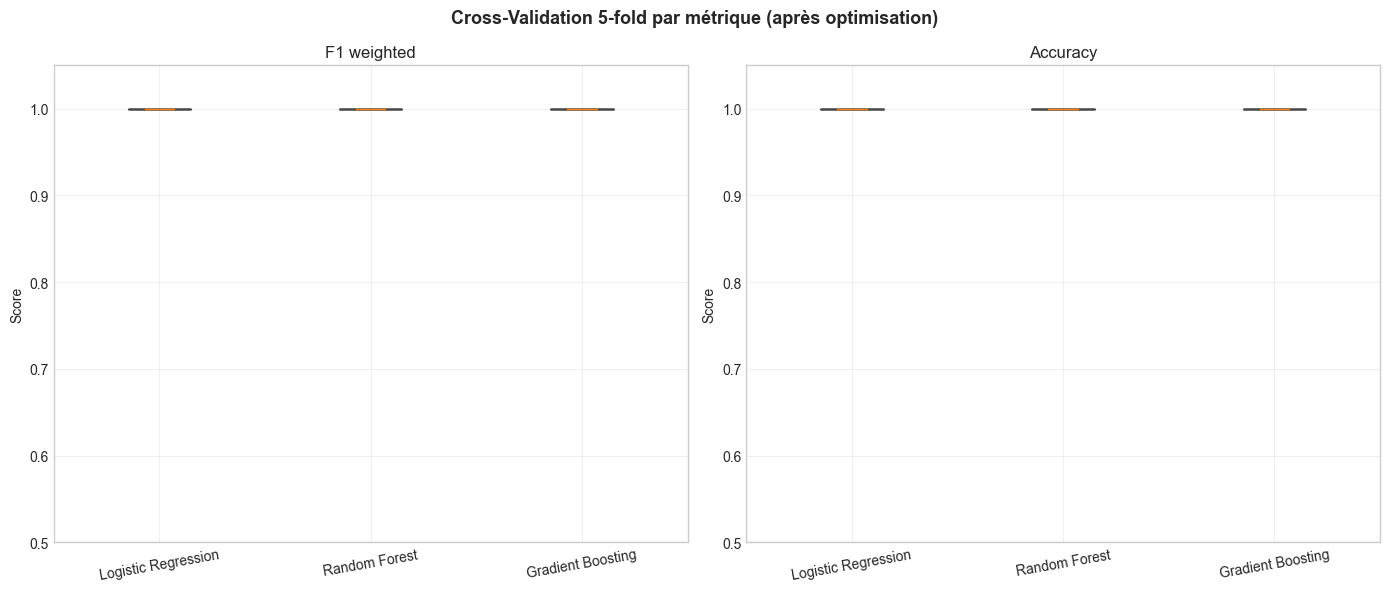

La hauteur de la boîte = variance entre les folds. Une boîte étroite = modèle stable.


In [13]:
# Cross-validation sur plusieurs métriques après optimisation
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

metrics_cv = {
    'F1 weighted' : 'f1_weighted',
    'Accuracy' : 'accuracy',
    'Precision macro': 'precision_macro',
    'Recall macro' : 'recall_macro',
}

cv_results_detail = {}
print("Cross-validation 5-fold (modèles optimisés)\n")
print(f"{'Modèle':<22} {'Métrique':<20} {'Moyenne':>8} {'Std':>8} {'Min':>8} {'Max':>8}")

for name, model in optimized_models.items():
    cv_results_detail[name] = {}
    for metric_name, metric_str in metrics_cv.items():
        scores = cross_val_score(model, X_train_sc, y_train, cv=cv_outer, scoring=metric_str, n_jobs=-1)
        cv_results_detail[name][metric_name] = scores
        print(f"{name:<22} {metric_name:<20} {scores.mean():>8.4f} {scores.std():>8.4f} {scores.min():>8.4f} {scores.max():>8.4f}")
    print()

# Visualisation boxplot des scores CV
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Cross-Validation 5-fold par métrique (après optimisation)', fontsize=13, fontweight='bold')

for ax, metric_name in zip(axes, ['F1 weighted', 'Accuracy']):
    data_box = [cv_results_detail[n][metric_name] for n in optimized_models]
    bp = ax.boxplot(data_box, labels=list(optimized_models.keys()), patch_artist=True, notch=True)
    colors_box = ['#1f77b4', '#ff7f0e', '#2ca02c']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(f'{metric_name}', fontsize=12)
    ax.set_ylabel('Score')
    ax.set_ylim(0.5, 1.05)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()
print("La hauteur de la boîte = variance entre les folds. Une boîte étroite = modèle stable.")


## Comparaison AVANT / APRÈS optimisation


 Résumé AVANT / APRÈS RandomizedSearchCV
                     F1 Avant  F1 Après  Delta F1  CV Score
Modèle                                                     
Logistic Regression    0.9820    1.0000    0.0180    1.0000
Random Forest          1.0000    1.0000    0.0000    1.0000
Gradient Boosting      1.0000    1.0000    0.0000    1.0000


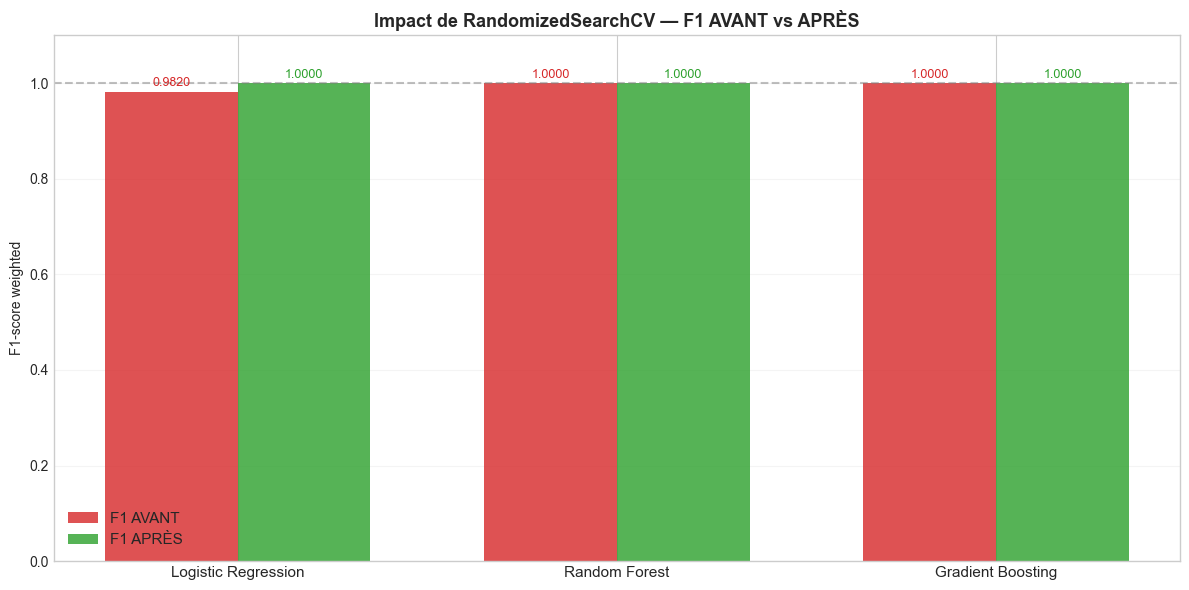

In [14]:
# Tableau comparatif AVANT / APRÈS
print("\n Résumé AVANT / APRÈS RandomizedSearchCV")
print(df_search[['F1 Avant', 'F1 Après', 'Delta F1', 'CV Score']].to_string())

# Visualisation barres groupées AVANT vs APRÈS
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(df_search))
width = 0.35

bars1 = ax.bar(x - width/2, df_search['F1 Avant'], width, label='F1 AVANT', color='#d62728', alpha=0.8)
bars2 = ax.bar(x + width/2, df_search['F1 Après'], width, label='F1 APRÈS', color='#2ca02c', alpha=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9, color='#d62728')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9, color='#2ca02c')

ax.set_xticks(x)
ax.set_xticklabels(df_search.index, fontsize=11)
ax.set_ylabel('F1-score weighted')
ax.set_title('Impact de RandomizedSearchCV — F1 AVANT vs APRÈS', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.axhline(y=df_results['F1'].max(), color='gray', linestyle='--', alpha=0.5, label='Baseline max')
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.show()


## Learning Curves (Après optimisation)

On compare les learning curves **avant** et **après** pour voir si l'optimisation a réduit l'overfitting et amélioré la généralisation.

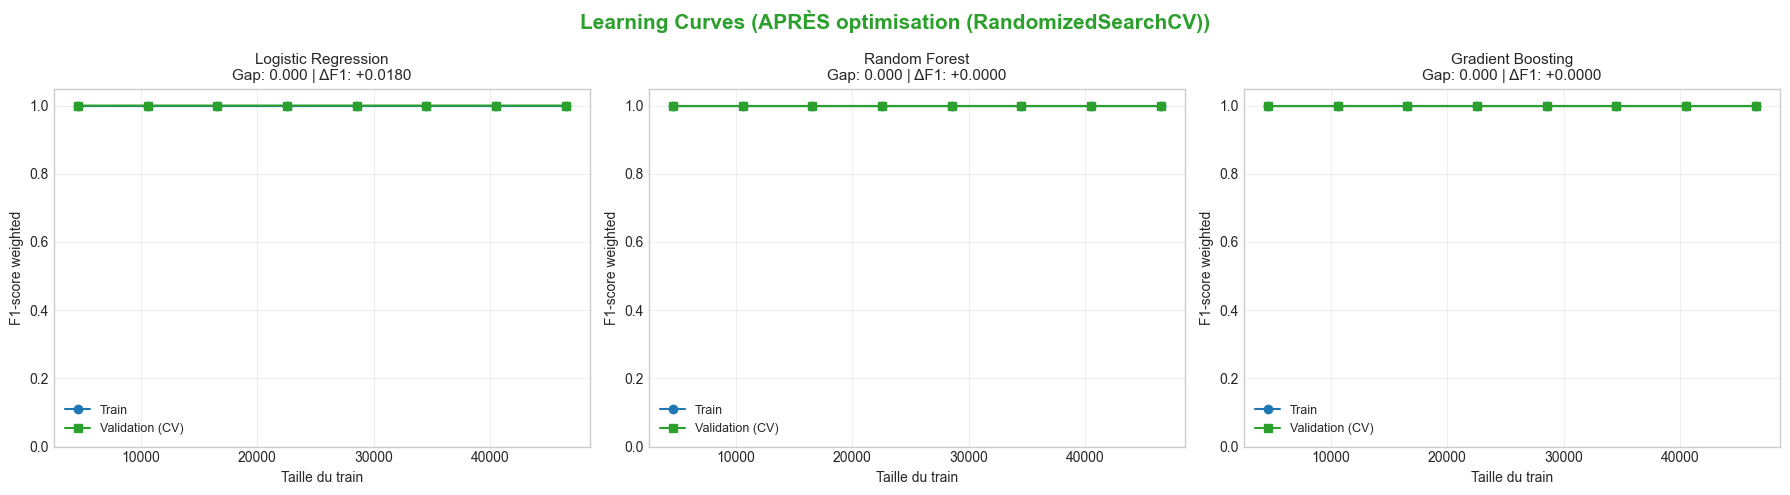

Comparer les gaps AVANT / APRÈS : un gap réduit = moins d'overfitting grâce à l'optimisation


In [15]:
# Learning curves APRÈS optimisation
fig, axes = plt.subplots(1, len(optimized_models), figsize=(18, 5))
fig.suptitle('Learning Curves (APRÈS optimisation (RandomizedSearchCV))', fontsize=15, fontweight='bold', color='#2ca02c')

for ax, (name, model) in zip(axes, optimized_models.items()):
    train_sz, train_scores, val_scores = learning_curve(
        model, X_train_sc, y_train,
        train_sizes=np.linspace(0.1, 1.0, 8),
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring='f1_weighted',
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std  = val_scores.std(axis=1)

    ax.plot(train_sz, train_mean, 'o-', color='#1f77b4', label='Train')
    ax.fill_between(train_sz, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#1f77b4')
    ax.plot(train_sz, val_mean, 's-', color='#2ca02c', label='Validation (CV)')
    ax.fill_between(train_sz, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#2ca02c')

    gap = (train_mean[-1] - val_mean[-1])
    f1_delta = df_search.loc[name, 'Delta F1']
    ax.set_title(f'{name}\nGap: {gap:.3f} | ΔF1: {f1_delta:+.4f}', fontsize=11)
    ax.set_xlabel('Taille du train')
    ax.set_ylabel('F1-score weighted')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Comparer les gaps AVANT / APRÈS : un gap réduit = moins d'overfitting grâce à l'optimisation")


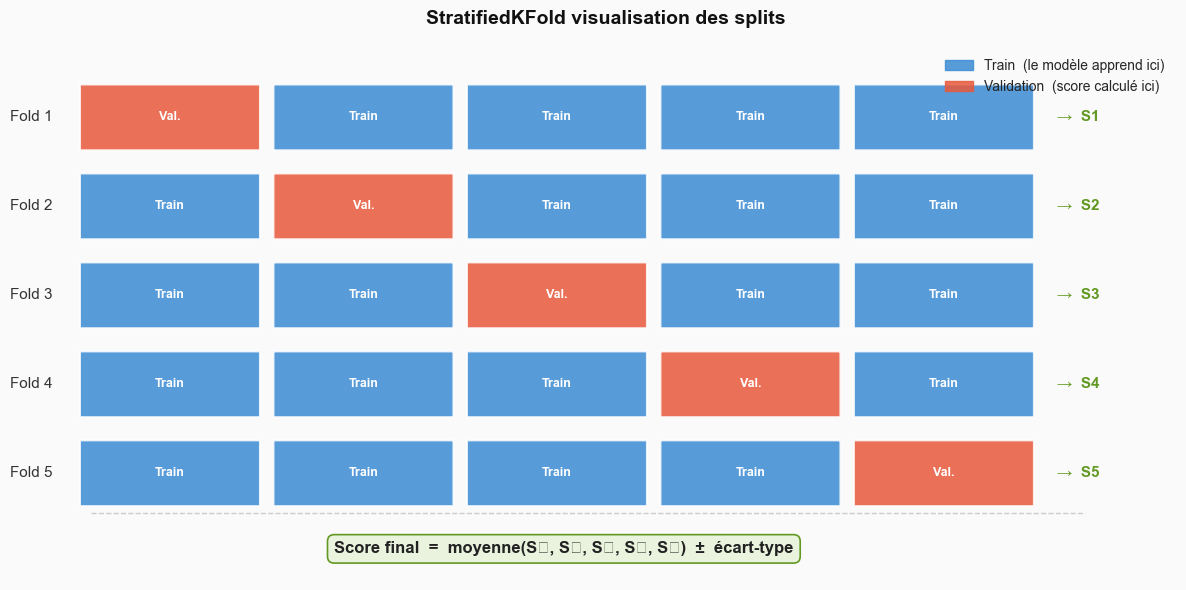

In [22]:
n_splits = 5
n_samples = 100
colors = {'train': '#3B8BD4', 'val': '#E8593C'}
fold_size = n_samples // n_splits

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

for fold in range(n_splits):
    for block in range(n_splits):
        x_start = block * (fold_size + 1)
        role = 'val' if block == fold else 'train'
        rect = FancyBboxPatch(
            (x_start, n_splits - fold - 0.85), fold_size - 0.5, 0.7,
            boxstyle="round,pad=0.02", facecolor=colors[role],
            edgecolor='white', linewidth=1.5, alpha=0.85
        )
        ax.add_patch(rect)
        ax.text(x_start + (fold_size - 0.5) / 2, n_splits - fold - 0.5,
                "Val." if role == 'val' else "Train",
                ha='center', va='center', fontsize=9, fontweight='bold', color='white')

    ax.text(-3, n_splits - fold - 0.5, f"Fold {fold + 1}",
            ha='right', va='center', fontsize=11, color='#333')
    ax.text(n_splits * (fold_size + 1) + 1, n_splits - fold - 0.5,
            f"→  S{fold + 1}", ha='left', va='center', fontsize=11,
            color='#639922', fontweight='bold')

ax.axhline(y=0.05, color='#ccc', linewidth=1, linestyle='--', xmin=0.05, xmax=0.92)
ax.text(n_splits * (fold_size + 1) / 2, -0.35,
        "Score final  =  moyenne(S₁, S₂, S₃, S₄, S₅)  ±  écart-type",
        ha='center', va='center', fontsize=12, fontweight='bold', color='#222',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#EAF3DE', edgecolor='#639922', linewidth=1.2))

ax.legend(handles=[
    mpatches.Patch(color='#3B8BD4', label='Train  (le modèle apprend ici)', alpha=0.85),
    mpatches.Patch(color='#E8593C', label='Validation  (score calculé ici)', alpha=0.85),
], loc='upper right', fontsize=10, framealpha=0.9, edgecolor='#ddd')

ax.set_xlim(-5, n_splits * (fold_size + 1) + 14)
ax.set_ylim(-0.7, n_splits + 0.3)
ax.set_title("StratifiedKFold visualisation des splits", fontsize=14, fontweight='bold', pad=16, color='#111')
ax.axis('off')
plt.tight_layout()
plt.show()

## Meilleur modèle optimisé

 Meilleur modèle optimisé : Logistic Regression
F1 AVANT : 0.9820
F1 APRÈS : 1.0000

 Rapport de classification (modèle optimisé) :
                  precision    recall  f1-score   support

   Bien desservi       1.00      1.00      1.00      1769
Desserte Normale       1.00      1.00      1.00      4592
   Sous-desservi       1.00      1.00      1.00      8153

        accuracy                           1.00     14514
       macro avg       1.00      1.00      1.00     14514
    weighted avg       1.00      1.00      1.00     14514



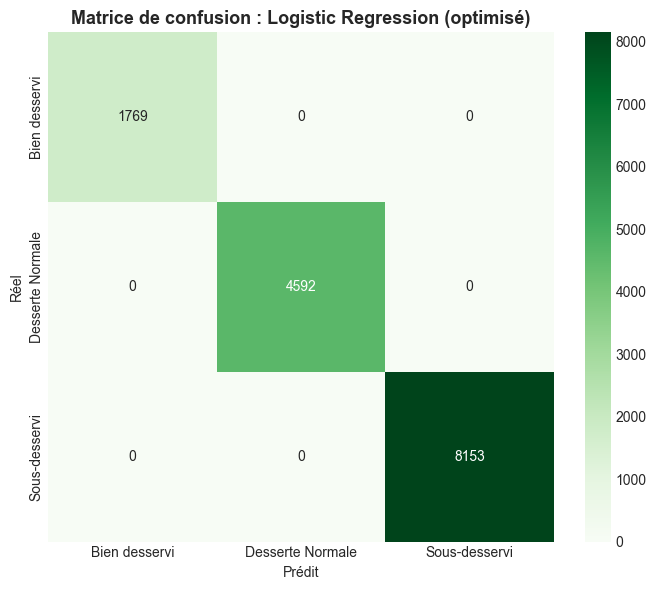

In [17]:
# Sélection du meilleur modèle après optimisation
best_opt_name = df_search['F1 Après'].idxmax()
best_opt_model = optimized_models[best_opt_name]
print(f" Meilleur modèle optimisé : {best_opt_name}")
print(f"F1 AVANT : {df_search.loc[best_opt_name, 'F1 Avant']:.4f}")
print(f"F1 APRÈS : {df_search.loc[best_opt_name, 'F1 Après']:.4f}")

y_pred_final = best_opt_model.predict(X_test_sc)
class_names = target.classes_

print("\n Rapport de classification (modèle optimisé) :")
print(classification_report(y_test, y_pred_final, target_names=class_names))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title(f'Matrice de confusion : {best_opt_name} (optimisé)', fontsize=13, fontweight='bold')
ax.set_ylabel('Réel')
ax.set_xlabel('Prédit')
plt.tight_layout()
plt.show()


## Meilleur modèle Analyse détaillée

In [18]:
# Sélection automatique sur F1 Macro
best_model_name = df_results['F1'].idxmax()
best_model = models[best_model_name]
print(f"Meilleur modèle : {best_model_name}")
print(f"F1 = {df_results.loc[best_model_name, 'F1']:.4f}")

Meilleur modèle : Random Forest
F1 = 1.0000


Rapport de classification
                  precision    recall  f1-score   support

   Bien desservi       1.00      1.00      1.00      1769
Desserte Normale       1.00      1.00      1.00      4592
   Sous-desservi       1.00      1.00      1.00      8153

        accuracy                           1.00     14514
       macro avg       1.00      1.00      1.00     14514
    weighted avg       1.00      1.00      1.00     14514



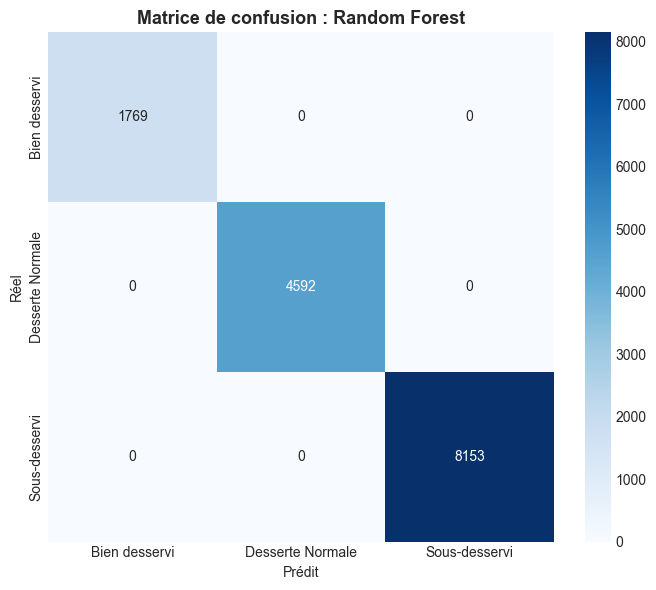

In [19]:
y_pred_best = best_model.predict(X_test_sc)
class_names = target.classes_

print("Rapport de classification")
print(classification_report(y_test, y_pred_best, target_names=class_names))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title(f'Matrice de confusion : {best_model_name}', fontsize=13, fontweight='bold')
ax.set_ylabel('Réel')
ax.set_xlabel('Prédit')
plt.tight_layout()
plt.show()

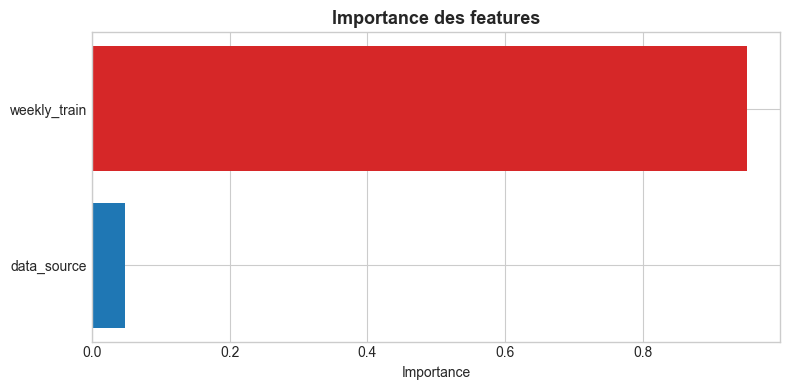

In [20]:
# Feature importance
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_names  = ['data_source', 'weekly_train']
    fi_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})\
              .sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(8, 4))
    colors_bar = ['#d62728' if i == fi_df['Importance'].idxmax() else '#1f77b4'
                  for i in fi_df.index]
    ax.barh(fi_df['Feature'], fi_df['Importance'], color=colors_bar)
    ax.set_title('Importance des features', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    print("Logistic Regression coefficients par classe :")
    feat_names = ['data_source', 'weekly_train']
    for i, cls in enumerate(class_names):
        print(f"  {cls}: {dict(zip(feat_names, best_model.coef_[i].round(3)))}")

## Export des résultats

In [21]:
OUTPUT_DIR = './'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Modèle
joblib.dump({
    'model'        : best_model,
    'model_name'   : best_model_name,
    'scaler'       : scaler,
    'source'    : source,   # encodeur data_source
    'target'    : target,      # encodeur desserte_type
    'feature_cols' : FEATURE_COLS,
}, os.path.join(OUTPUT_DIR, 'classification.pkl'))
print(f'Modèle ({best_model_name}) sauvegardé : {OUTPUT_DIR}/classification.pkl')

Modèle (Random Forest) sauvegardé : .//classification.pkl
